# Extracting and Visualising Subhalo Particle Data from IllustrisTNG

This notebook demonstrates how to:

1. Load subhalo particle data (DM, gas, stars) from TNG simulations.
2. Access different particle properties: positions, velocities, masses, potentials.
3. Apply a physical conversion to kpc and km/s units.
4. Recenter particles using the shrinking sphere method.
5. Subsample particles for faster plotting.
6. Create 2D projections of particle distributions.


In [2]:
import h5py
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import struct
from scipy.optimize import curve_fit
import time
import illustris_python as il
import astropy


In [6]:
import sys
sys.path.append('/home/tnguser/TNGCluster')

from astro_utils.function_coord import *
from astro_utils.function_plot import *
from astro_utils.spherical_coord import *
from astro_utils.utils_astro import *
from astro_utils.IllustrisTNG_functions.Get_Particles_snap import *

from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units  as u
from scipy.stats import binned_statistic
from collections import OrderedDict


In [7]:
# Take 10% of particles for speed
frac = 0.1

def sample_arrays(x, y, z, frac=0.1):
    n = len(x)
    n_sample = max(1, int(frac * n))
    idx = np.random.choice(np.arange(n), n_sample, replace=False)
    return x[idx], y[idx], z[idx]

In [8]:
basePath_tngcluster = '/home/tnguser/sims.TNG/TNG-Cluster/output'
basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'
basePath_tng100 = '/home/tnguser/sims.TNG/TNG100-1/output'
basePath_tng300 = '/home/tnguser/sims.TNG/TNG300-1/output'

base_out = '/home/tnguser/TNGCluster/'

G=43007.1/1.e10     # Constante de Newton en unidades de masas solares
#mass_DM_particle = 3.07367708626464e-05 # TNG50
#mass_DM_particle = 5.05574296e-04 # TNG100
mass_DM_particle = 0.00074374 # TNG300 + TNGCluster

##########Track subfind_number_z0 from zmin to zmax.  #############
nz=4
zmin = 0
zmax = 1

# Plot the xy and xz proyections of gas, stars, dm

Processing snapshot 99...


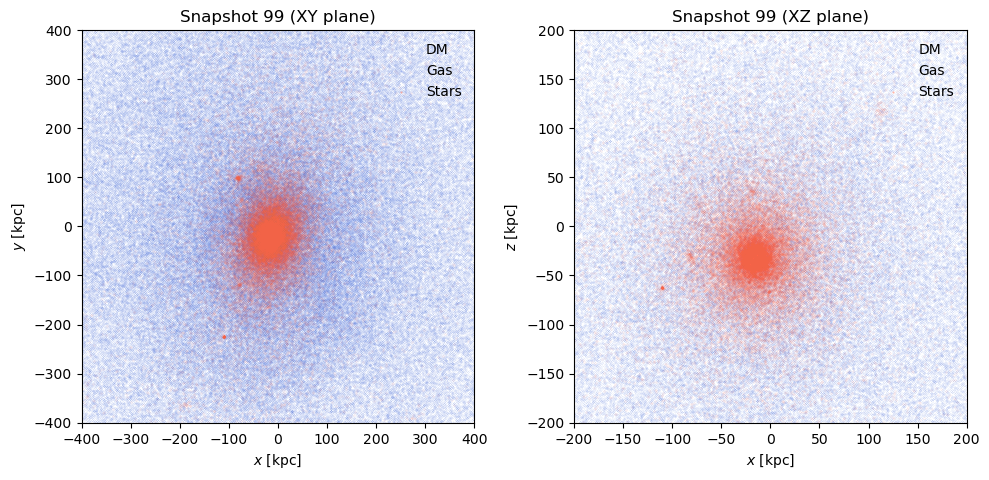

Processing snapshot 76...


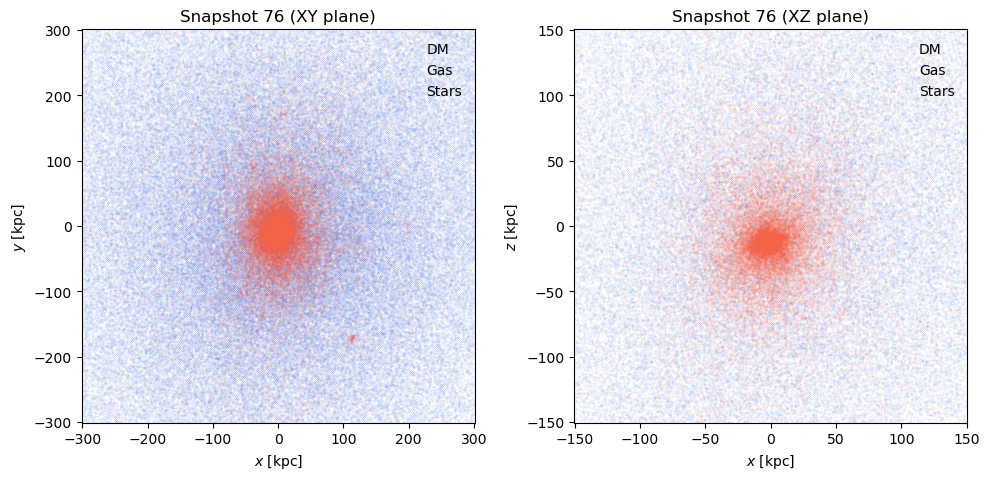

Processing snapshot 60...


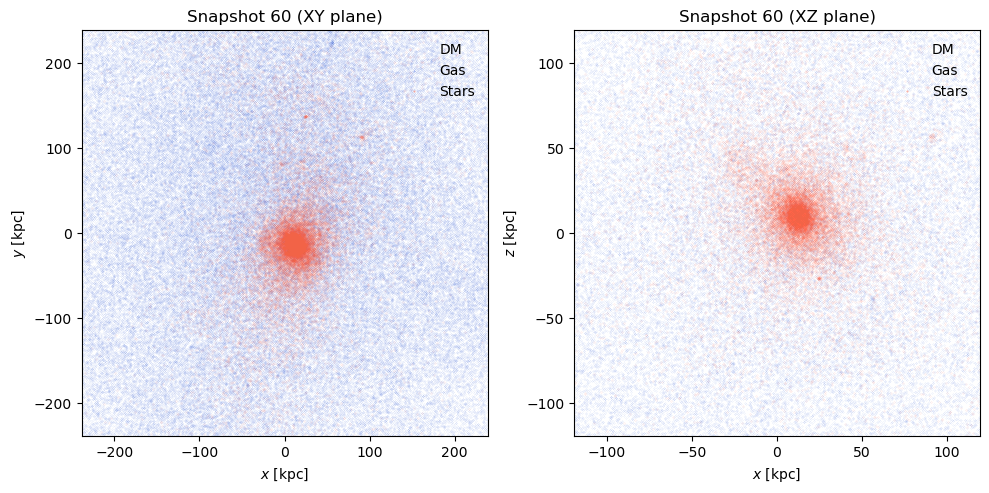

Processing snapshot 50...


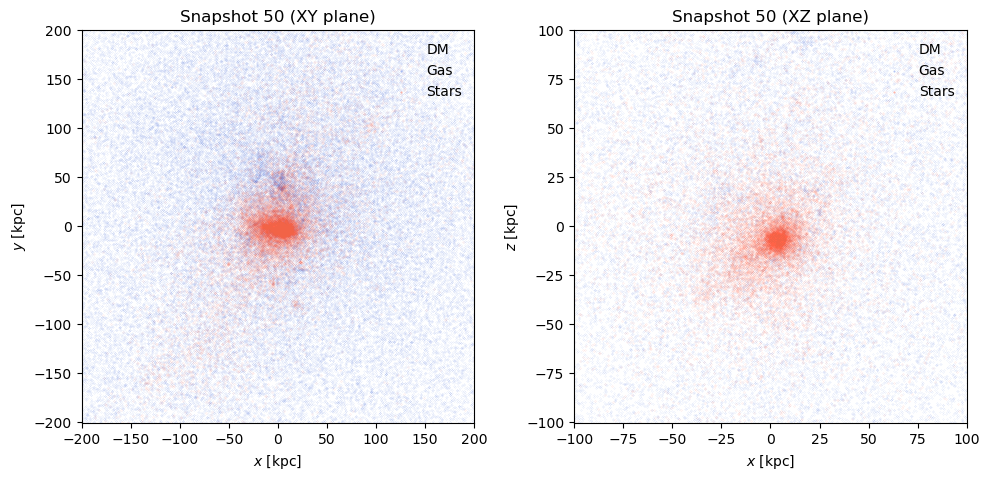

In [9]:
############## Data ##############

snap_number=99 
subfind_number_z0= 7289457

####### List of snap vs z vs aex ########

data = np.load(base_out+"snap_vs_z.npz")
snap_selected = data['snaparr']
z_selected = data['zselected']
aexp_selected = data['aexselected']

######## Track ########

snap_lista= []
z_wanted = np.linspace(zmin,zmax, nz)    
z_wanted = list(z_wanted)

for z in z_wanted:
    idx = find_nearest(z_selected, z)
    snap_lista.append(int(snap_selected[idx]))

snap_lista = list(OrderedDict.fromkeys(snap_lista))
z_wanted = list(np.around(np.array(z_wanted),2))

###########Track ids of subfind_number_z0 for z_wanted ########

fields = ['SubhaloMass','SubfindID','SnapNum']
tree = il.sublink.loadTree(basePath_tngcluster, 99, subfind_number_z0, fields=fields, onlyMPB=True)
SnapTree = tree['SnapNum']
SubfindIDTree = tree['SubfindID']
mass_msun = tree['SubhaloMass'] * 1e10 / 0.6774

a = SnapTree
b = set(snap_lista)
c =[i for i, item in enumerate(a) if item in b]

subfind_number = SubfindIDTree[c] # The target galaxy from subfind_number_z0
mass_msun = mass_msun[c]


############ FoF and Subfind ###########
for m, snap_number in enumerate(snap_lista):
    print(f'Processing snapshot {snap_number}...')

    Header = il.groupcat.loadHeader(basePath_tngcluster, snap_number)
    redsh = Header['Redshift'][()]
    aexp = Header['Time'][()]
    hh = Header['HubbleParam'][()]
    Omega0 = Header['Omega0'][()]
    OmegaLambda = Header['OmegaLambda'][()]
    cosmo = FlatLambdaCDM(H0=hh * 100, Om0=Omega0)
    Hubb = cosmo.H(redsh).to(u.km / u.kpc / u.s).value
    adot = Hubb * aexp
    rho_crit = cosmo.critical_density(redsh).to(u.Msun / u.kpc**3).value

    # --- Group and subhalo data ---
    subhalo = il.groupcat.loadSingle(basePath_tngcluster, snap_number, subhaloID=subfind_number[m])
    SubhaloPos = np.array(subhalo['SubhaloPos']) / hh
    SubhaloGrNr = subhalo['SubhaloGrNr']
    SubhaloMass = subhalo['SubhaloMass'] * 1e10 / hh

    halo = il.groupcat.loadSingle(basePath_tngcluster, snap_number, haloID=SubhaloGrNr)
    Group_R_Crit200 = halo['Group_R_Crit200'] * aexp
    Group_M_Crit200 = halo['Group_M_Crit200'] * 1e10 / hh
    GroupPos = halo['GroupPos'] / hh
    GroupVel = halo['GroupVel']

    # --- Physical coordinates and velocities of the group ---
    cmx, cmy, cmz = (GroupPos * aexp)
    vcmx, vcmy, vcmz = (GroupVel * aexp**-1 + GroupPos * adot / hh)
    center = np.array([cmx, cmy, cmz])
    vcenter = np.array([vcmx, vcmy, vcmz])

    ################## Load particle data #################
    dm = snap_phy_subhalo(basePath_tngcluster, snap_number, subfind_number[m], 1, aexp, adot, hh)
    gas = snap_phy_subhalo(basePath_tngcluster, snap_number, subfind_number[m], 0, aexp, adot, hh, ['Masses'])
    star = snap_phy_subhalo(basePath_tngcluster, snap_number, subfind_number[m], 4, aexp, adot, hh, ['Masses', 'Potential'])

    # Dark Matter
    xdm, ydm, zdm = dm['pos'].T
    vxdm, vydm, vzdm = dm['vel'].T
    nDM = len(xdm)
    mDM = np.ones(nDM) * mass_DM_particle * 1e10

    # Stars
    xstar, ystar, zstar = star['pos'].T
    vxstar, vystar, vzstar = star['vel'].T
    ms = star['mass']
    ebin_s = star['pot']

    # Gas
    xgas, ygas, zgas = gas['pos'].T
    vxgas, vygas, vzgas = gas['vel'].T
    mg = gas['mass']

    ######## Recalculate the center of mass ########
    flag_cm = 1
    if flag_cm > 0:
        pos_star = star['pos']
        vel_star = star['vel']
        xcm, ycm, zcm, vxcm, vycm, vzcm = shrinking_sphere(pos_star, vel_star, ms)
    else:
        xcm, ycm, zcm, vxcm, vycm, vzcm = cmx, cmy, cmz, vcmx, vcmy, vcmz

    center = np.array([xcm, ycm, zcm])
    vcenter = np.array([vxcm, vycm, vzcm])

    ################ Relative coordinates #################
    # Stars
    pos_star_rel = star['pos'] - center
    vel_star_rel = star['vel'] - vcenter
    rpristar = np.linalg.norm(pos_star_rel, axis=1)
    order = np.argsort(rpristar)
    rpristar_ord = rpristar[order]
    mstar_ord = ms[order]
    ns = len(mstar_ord)

    # Gas
    pos_gas_rel = gas['pos'] - center
    vel_gas_rel = gas['vel'] - vcenter
    rprigas = np.linalg.norm(pos_gas_rel, axis=1)
    order = np.argsort(rprigas)
    rprigas_ord = rprigas[order]
    mgas_ord = mg[order]
    ng = len(mgas_ord)

    # DM
    pos_dm_rel = dm['pos'] - center
    vel_dm_rel = dm['vel'] - vcenter
    rpridark = np.linalg.norm(pos_dm_rel, axis=1)
    order = np.argsort(rpridark)
    rpridark_ord = rpridark[order]
    mdark_ord = mDM[order]
    nDM = len(mdark_ord)
    # Plotting ##########
    frac = 0.1
    
    # Sample 10% for each component
    xstar_s, ystar_s, zstar_s = sample_arrays(pos_star_rel[:, 0], pos_star_rel[:, 1], pos_star_rel[:, 2], frac)
    xgas_s, ygas_s, zgas_s = sample_arrays(pos_gas_rel[:, 0], pos_gas_rel[:, 1], pos_gas_rel[:, 2], frac)
    xdm_s, ydm_s, zdm_s = sample_arrays(pos_dm_rel[:, 0], pos_dm_rel[:, 1], pos_dm_rel[:, 2], frac)
    
    # Set Image ##

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # XY plane
    ax1.scatter(xdm_s, ydm_s, s=1e-5, color='grey', alpha=0.1, label='DM',zorder=0)
    ax1.scatter(xgas_s, ygas_s, s=1e-2, color='royalblue', alpha=0.4, label='Gas',zorder=1)
    ax1.scatter(xstar_s, ystar_s, s=1e-2, color='tomato', alpha=0.5, label='Stars',zorder=2)
    ax1.set_xlabel(r'$x$ [kpc]')
    ax1.set_ylabel(r'$y$ [kpc]')
    ax1.set_aspect('equal', 'box')
    ax1.set_xlim(-400*aexp, 400*aexp)
    ax1.set_ylim(-400*aexp, 400*aexp)
    ax1.legend(frameon=False, loc='upper right', markerscale=5)
    ax1.set_title(f'Snapshot {snap_number} (XY plane)')

    # XZ plane
    ax2.scatter(xdm_s, zdm_s, s=1e-5, color='grey', alpha=0.1, label='DM',zorder=0)
    ax2.scatter(xgas_s, zgas_s, s=1e-2, color='royalblue', alpha=0.4, label='Gas',zorder=1)
    ax2.scatter(xstar_s, zstar_s, s=1e-2, color='tomato', alpha=0.5, label='Stars',zorder=2)
    ax2.set_xlabel(r'$x$ [kpc]')
    ax2.set_ylabel(r'$z$ [kpc]')
    ax2.set_aspect('equal', 'box')
    ax2.set_xlim(-200*aexp, 200*aexp)
    ax2.set_ylim(-200*aexp, 200*aexp)
    ax2.legend(frameon=False, loc='upper right', markerscale=5)
    ax2.set_title(f'Snapshot {snap_number} (XZ plane)')

    plt.tight_layout()
    plt.show()



# Save every progenitor of our selected galaxies in a z range

Pos, Vel, Mass and different radius to a Table  (can add Tempeture, Z, whatever..)

In [3]:
ngal=20


grouparr = np.zeros(ngal)
subgrouparr = np.zeros(ngal)

rhm=np.zeros(ngal)          # Half mass radius
ropt=np.zeros(ngal)         # Optical radius (~80% of baryonic mass)
ropt_st=np.zeros(ngal)      # Optical radius (sólo de las estrellas)    
mgal_tot=np.zeros(ngal)     # Masa total de la galaxia principal 
mstar_ropt=np.zeros(ngal)   # Masa de estrellas en la galaxia principal
mgas_ropt=np.zeros(ngal)    # Masa de gas en la galaxia principal
mgal_ropt=np.zeros(ngal)    # Masa de la galaxia dentro del radio óptico

xcm=np.zeros(ngal)    # Relativo al centro de masas de la galaxia principal
ycm=np.zeros(ngal)  
zcm=np.zeros(ngal)  
vxcm=np.zeros(ngal)  
vycm=np.zeros(ngal)  
vzcm=np.zeros(ngal)  

r_vir = np.zeros(ngal)
mdm_rvir = np.zeros(ngal)  # masa de DM dentro del rvir
mgas_rvir = np.zeros(ngal)  # masa de gas dentro del rvir
mstar_rvir = np.zeros(ngal)  # masa de estrellas dentro del rvir

mdm_20_rvir = np.zeros(ngal)  # masa de DM dentro del 20%rvir
mgas_20_rvir = np.zeros(ngal)  # masa de gas dentro del 20%rvir
mstar_20_rvir = np.zeros(ngal)  # masa de estrellas dentro del 20%rvir

rho_crit_arr= np.zeros(ngal)*float('nan') 
aexp_arr = np.zeros(ngal)*float('nan') 
z_arr= np.zeros(ngal)*float('nan') 
delta_c_arr = np.zeros(ngal)*float('nan')

flag_cm = 1
flag_dens = 1
flag_vsigma = 1
flag_causticplot = 1
flag_histplot = 0
flag_galplot = 0
flag_galplot_vaex = 0
flag_epsilon = 1


In [ ]:
import sys
from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units  as u
from scipy.stats import binned_statistic
from collections import OrderedDict

basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'
base_out = '/home/tnguser/output/'

################ Define the ID #########
G=43007.1/1.e10     # Constante de Newton en unidades de masas solares


data = np.load(base_out+"snap_vs_z.npz")

snap_selected = data['snaparr']
z_selected = data['zselected']
aexp_selected = data['aexselected']

snap_lista= []
z_wanted = np.linspace(0,4, ngal)    
z_wanted = list(z_wanted)
for z in z_wanted:
    idx = find_nearest(z_selected, z)
    snap_lista.append(int(snap_selected[idx]))

snap_lista = list(OrderedDict.fromkeys(snap_lista))
z_wanted = list(np.around(np.array(z_wanted),2))


subfind_number_z0= 476266

fields = ['SubhaloMass','SubfindID','SnapNum']
tree = il.sublink.loadTree(basePath_tng50, 99, subfind_number_z0, fields=fields, onlyMPB=True)
SnapTree = tree['SnapNum']
SubfindIDTree = tree['SubfindID']
mass_msun = tree['SubhaloMass'] * 1e10 / 0.6774

a = SnapTree
b = set(snap_lista)
c =[i for i, item in enumerate(a) if item in b]

subfind_number = SubfindIDTree[c]
mass_msun = mass_msun[c]

############ FoF and Subfind ###########
for m,snap_number in enumerate(snap_lista):
    print('snap_number',snap_number)
    Header = il.groupcat.loadHeader(basePath_tng50, snap_number)

    redsh = Header['Redshift'][()]
    aexp = Header['Time'][()]
    hh = Header['HubbleParam'][()]
    Omega0 = Header['Omega0'][()]
    OmegaLambda = Header['OmegaLambda'][()]
    Omega = Omega0+OmegaLambda
    OmegaR = 0

    ############## cosmo ###################
    cosmo = FlatLambdaCDM(H0=hh*100, Om0=Omega0)
    Hubb =  cosmo.H(redsh).to(u.km/u.kpc/u.s)  
    adot = Hubb*aexp     
    adot = adot.value
    rho_crit = cosmo.critical_density(redsh).to(u.Msun/u.kpc**3)             
    rho_crit = rho_crit.value 
    
    rho_crit_arr[m]= rho_crit   
    aexp_arr[m] = aexp
    z_arr[m]= redsh        
    
    subhalos_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,subhaloID=subfind_number[m])#,fields=['SubhaloGrNr','SubhaloMass','SubhaloPos'])
    SubhaloPos = np.array(subhalos_tng50['SubhaloPos'])
    SubhaloGrNr = np.array(subhalos_tng50['SubhaloGrNr'])
    SubhaloMass = np.array(subhalos_tng50['SubhaloMass'])*1e10/hh
    
    grouparr[m] = SubhaloGrNr
    subgrouparr[m] = subfind_number[m]

    halos99_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,haloID=SubhaloGrNr)#,fields=['Group_R_Crit200','Group_M_Crit200','GroupPos'])
    Group_R_Crit200_tng50 =  np.array(halos99_tng50['Group_R_Crit200'])
    Group_M_Crit200_tng50 =  np.array(halos99_tng50['Group_M_Crit200'])*1e10/hh
    GroupPos =  np.array(halos99_tng50['GroupPos'])
    GroupVel =  np.array(halos99_tng50['GroupVel'])

    ################## Snap #############################
    fields_part_dm = ['Velocities','Coordinates']
    dm_sub = il.snapshot.loadSubhalo(basePath_tng50, snap_number,subfind_number[m] , 1, fields=fields_part_dm)


    fields_part_gas = ['Velocities','Coordinates','Masses']
    gas_sub = il.snapshot.loadSubhalo(basePath_tng50, snap_number,subfind_number[m] , 0, fields=fields_part_gas)


    fields_part_stars = ['Velocities','Coordinates','Potential','Masses']
    star_sub = il.snapshot.loadSubhalo(basePath_tng50, snap_number,subfind_number[m] , 4, fields=fields_part_stars)

    ################## decompose ##################
    rvirFoF = Group_R_Crit200_tng50
    rvirFoF*= aexp 
    center =GroupPos
    cmx = center[0]
    cmy = center[1]
    cmz = center[2]
    
    cmx *= aexp  
    cmy *= aexp   
    cmz *= aexp 
    
    xcm[m]=cmx
    ycm[m]=cmy
    zcm[m]=cmz
    
    vcenter =GroupVel

    vcmx = vcenter[0]
    vcmy = vcenter[1]
    vcmz = vcenter[2]
    
    vcmx= vcmx* aexp**(-1) + cmx * adot * hh**(-1)
    vcmy= vcmy* aexp**(-1) + cmy * adot * hh**(-1)
    vcmz= vcmz* aexp**(-1) + cmz * adot * hh**(-1)

    
    ################### dm ########################
    dm_pos = dm_sub['Coordinates']

    xdm = np.array(dm_pos[:, 0])
    ydm = np.array(dm_pos[:, 1])
    zdm = np.array(dm_pos[:, 2])

    xdm *= aexp 
    ydm *= aexp   
    zdm *= aexp     

    dm_vel = dm_sub['Velocities']

    vxdm = np.array(dm_vel[:, 0])
    vydm = np.array(dm_vel[:, 1])
    vzdm = np.array(dm_vel[:, 2])

    vxdm= vxdm * aexp**(0.5) + xdm * adot * hh**(-1)
    vydm= vydm * aexp**(0.5) + ydm * adot * hh**(-1)
    vzdm= vzdm * aexp**(0.5) + zdm * adot * hh**(-1)   

    nDM = len(xdm)
    mDM = np.ones(nDM)*3.07367708626464e-05
    mDM *= 1e10

    ################ stars ################

    star_pos = star_sub['Coordinates']

    xstar = np.array(star_pos[:, 0])
    ystar = np.array(star_pos[:, 1])
    zstar = np.array(star_pos[:, 2])

    xstar *= aexp 
    ystar *= aexp   
    zstar *= aexp     

    star_vel = star_sub['Velocities']

    vxstar = np.array(star_vel[:, 0])
    vystar = np.array(star_vel[:, 1])
    vzstar = np.array(star_vel[:, 2])

    vxstar= vxstar * aexp**(0.5) + xstar * adot * hh**(-1)
    vystar= vystar * aexp**(0.5) + ystar * adot * hh**(-1)
    vzstar= vzstar * aexp**(0.5) + zstar * adot * hh**(-1)

    ms = star_sub['Masses']
    ms = ms*1e10*hh**(-1)
    
    ebin_s = star_sub['Potential']
    ebin_s /= aexp
    ################ gas ################

    gas_pos = gas_sub['Coordinates']

    xgas = np.array(gas_pos[:, 0])
    ygas = np.array(gas_pos[:, 1])
    zgas = np.array(gas_pos[:, 2])

    xgas *= aexp 
    ygas *= aexp   
    zgas *= aexp     

    gas_vel = gas_sub['Velocities']

    vxgas = np.array(gas_vel[:, 0])
    vygas = np.array(gas_vel[:, 1])
    vzgas = np.array(gas_vel[:, 2])

    vxgas= vxgas * aexp**(0.5) + xgas * adot * hh**(-1)
    vygas= vygas * aexp**(0.5) + ygas * adot * hh**(-1)
    vzgas= vzgas * aexp**(0.5) + zgas * adot * hh**(-1)   

    mg = gas_sub['Masses']
    mg = mg*1e10*hh**(-1)
    
    
    no_it = 0    
    if flag_cm > 0:
        # np.concatenate((a, b), axis=None) para añadir xgas
        xsh = np.concatenate((xstar, []), axis=None)
        ysh = np.concatenate((ystar, []), axis=None)
        zsh = np.concatenate((zstar, []), axis=None)
        vxsh = np.concatenate((vxstar, []), axis=None)
        vysh = np.concatenate((vystar, []), axis=None)
        vzsh = np.concatenate((vzstar, []), axis=None)               

        msh = np.concatenate((ms, []), axis=None)

        mtotal = np.sum(msh)
        #na = n_part
        #nlow = 0.1*n_part
        na = len(xstar)
        nlow = 0.1*len(xstar)

        xpri = xsh-cmx
        ypri = ysh-cmy   
        zpri = zsh-cmz
        rpri = np.sqrt(np.square(xpri)+np.square(ypri)+np.square(zpri))
        rmax = np.amax(rpri)
        cont = 0
        no_it = 0
        while ((na>=nlow) & (na>=100)):
            a = np.where(rpri <= (0.975*rmax))
            na = len(a[0])
            if na > 0:
                xcut = xsh[a]
                ycut = ysh[a]
                zcut = zsh[a]
                vxcut = vxsh[a]
                vycut = vysh[a]
                vzcut = vzsh[a]     
                mcut = msh[a]
                mtotal = np.sum(mcut)
                xcm0 = np.sum(xcut*mcut)/mtotal
                ycm0 = np.sum(ycut*mcut)/mtotal
                zcm0 = np.sum(zcut*mcut)/mtotal
                vxcm0 = np.sum(vxcut*mcut)/mtotal
                vycm0 = np.sum(vycut*mcut)/mtotal
                vzcm0 = np.sum(vzcut*mcut)/mtotal       
                xpri = xcut-xcm0
                ypri = ycut-ycm0
                zpri = zcut-zcm0
                rpri = np.sqrt(np.square(xpri)+np.square(ypri)+np.square(zpri))
                rmax = np.amax(rpri)
                xsh=xcut
                ysh=ycut
                zsh=zcut
                msh=mcut
                cont=cont+1
            else:
                print("No puedo iterar")  
                no_it = no_it+1
    #XXX Refiero al centro de masa calculado con shrsph XXX

        xcm[m] = xcm0
        ycm[m] = ycm0
        zcm[m] = zcm0
        vxcm[m] = vxcm0
        vycm[m] = vycm0
        vzcm[m] = vzcm0 
    else: # Si no se recalcula, se pone el del centro de masas del grupo (real que sale fatal)
        xcm[m] = cmx
        ycm[m] = cmy
        zcm[m] = cmz

        vxcm[:]=vcmx
        vycm[:]=vcmy
        vzcm[:]=vcmz    
    
    xpristar=xstar-xcm[m]
    ypristar=ystar-ycm[m]
    zpristar=zstar-zcm[m]
    vxpristar=vxstar-vxcm[m]
    vypristar=vystar-vycm[m]
    vzpristar=vzstar-vzcm[m]
    rpristar = np.sqrt(np.square(xpristar)+np.square(ypristar)+np.square(zpristar)) 
    rpristar_ord = rpristar[rpristar.argsort()]       
    mstar_ord = ms[rpristar.argsort()]       
    ns= len(mstar_ord )

    #XXX Para el gas XXX
    
    xprigas=xgas-xcm[m]
    yprigas=ygas-ycm[m]
    zprigas=zgas-zcm[m]
    rprigas = np.sqrt(np.square(xprigas)+np.square(yprigas)+np.square(zprigas))
    vxprigas=vxgas-vxcm[m]
    vyprigas=vygas-vycm[m]
    vzprigas=vzgas-vzcm[m]
    rprigas_ord = np.sort(rprigas)
    mgas_ord = mg[rprigas.argsort()]        
    ng= len(mgas_ord )   

    #XXX Para el DM XXX
    xpridark=xdm-xcm[m]
    ypridark=ydm-ycm[m]
    zpridark=zdm-zcm[m]
    rpridark = np.sqrt(np.square(xpridark)+np.square(ypridark)+np.square(zpridark))
    vxpridark=vxdm-vxcm[m]
    vypridark=vydm-vycm[m]
    vzpridark=vzdm-vzcm[m]          
    rpridark_ord = np.sort(rpridark)
    mdark_ord = mDM[rpridark.argsort()] 
    nDM= len(mdark_ord) 

    #XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
    # Ropt with all baryons
    xgal = np.concatenate((xpristar, xprigas), axis=None)
    ygal = np.concatenate((ypristar, yprigas), axis=None)
    zgal = np.concatenate((zpristar, zprigas), axis=None)
    mgal = np.concatenate((ms, mg), axis=None)
    nbar = len(ms) + len(mg)
    rgal = np.sqrt(np.square(xgal)+np.square(ygal)+np.square(zgal))

    if np.sum(mgal) <= 0.123480*1e10: # Corte de Mari
        rcut = 50 * np.sqrt(np.sum(mgal)/1e10/0.7) * aexp    
    else:
        rcut = 30  * aexp

    # Ordenar las partículas según valor ascendente del radio
    sort_index = np.argsort(rgal)
    rgal_ord = rgal[sort_index]
    mgal_ord = mgal[sort_index]

    acut = np.where(rgal_ord <= rcut)
    ncut = len(acut[0]) 
    if ncut > 0:
        rgalcut = rgal_ord[acut]
        mgalcut = mgal_ord[acut]
        mcut = np.sum(mgalcut)

        massb50 = 0.83*mcut
        maux = 0
        t = 0
        while t<ncut:
            if maux<massb50:
                maux = maux + mgalcut[t]
                ropt[m]=rgalcut[t]

            t = t+1

    # Half Mass
    if ncut > 0:
        rgalcut = rgal_ord[acut]
        mgalcut = mgal_ord[acut]
        mcut = np.sum(mgalcut)

        massb50 = 0.50*mcut
        maux = 0
        t = 0
        while t<ncut:
            if maux<massb50:
                maux = maux + mgalcut[t]
                rhm[m]=rgalcut[t]

            t = t+1

    if (ng > 0):
        r_total_vir = np.concatenate((rpridark, rpristar, rprigas), axis=None)
        m_total_vir = np.concatenate((mDM, ms, mg), axis=None)
        ntotal_vir = nDM+ns+ng
    else:
        r_total_vir = np.concatenate((rpridark, rpristar), axis=None)
        m_total_vir = np.concatenate((mDM, ms), axis=None)
        ntotal_vir = nDM+ns

    r_total_vir_ord = np.sort(r_total_vir)
    m_total_vir_ord = m_total_vir[r_total_vir.argsort()]


    mtot = 0
    rvir = 0
    for j in range(ntotal_vir):
        mtot = mtot+m_total_vir_ord[j]
        voltot = (4./3.)*np.pi*r_total_vir_ord[j]**(3.)
        if (voltot != 0):
            rho_media = mtot/(voltot)
            if (rho_media > (200.*rho_crit)):
                rvir = r_total_vir_ord[j]

    #rvir = R200[group_number]*aexp
    #print(rvir,rvirFoF)
    rvir=rvirFoF
    r_vir[m] = rvir

    # *** guardo las masas y particulas en el Rvir ****
    avirh = np.where(rpridark <= rvir)
    navirh = len(avirh[0])

    #n_hvirarr[conta] = navirh

    if (navirh > 0):
        mdm_rvir[m] = np.sum(mDM[avirh])
    else:
        mdm_rvir[m] = 0

    avirg = np.where(rprigas <= rvir)
    navirg = len(avirg[0])

    if (navirg > 0):
        mgas_rvir[m] = np.sum(mg[avirg])
    else:
        mgas_rvir[m] = 0

    avirs = np.where(rpristar <= rvir)
    navirs = len(avirs[0])

    if (navirs > 0):
        mstar_rvir[m] = np.sum(ms[avirs])
    else:
        mstar_rvir[m] = 0

    # *** guardo las masas y particulas en el 20%Rvir ****
    avirh20 = np.where(rpridark <= 0.2*rvir)
    navirh20 = len(avirh20[0])

    if (navirh20 > 0):
        mdm_20_rvir[m] = np.sum(mDM[avirh20])
    else:
        mdm_20_rvir[m] = 0

    avirg20 = np.where(rprigas <=  0.2*rvir)
    navirg20 = len(avirg20[0])

    if (navirg20 > 0):
        mgas_20_rvir[m] = np.sum(mg[avirg20])
    else:
        mgas_20_rvir[m] = 0

    avirs20 = np.where(rpristar <=  0.2*rvir)
    navirs20 = len(avirs20[0])

    if (navirs20 > 0):
        mstar_20_rvir[m] = np.sum(ms[avirs20])
    else:
        mstar_20_rvir[m] = 0

    # Contar número de partículas que han entrado en el radio óptico
    aropt = np.where(rgal <= ropt[m])    
    narop = len(aropt[0])
    if narop > 0:
        mgal_ropt[m] = np.sum(mgal[aropt])
    else:
        mgal_ropt[m] = 0 

    dumpfile= base_out + 'Variables/h'+str(subfind_number_z0)+'/'
    if not os.path.exists(dumpfile):
        os.makedirs(base_out + 'Variables/h'+str(subfind_number_z0)+'/')
    data_file_path = base_out + '/Variables/h'+str(subfind_number_z0)+'/Variable_snap='+ str(snap_number) +'_'+ str(subfind_number[m])                           
    np.savez(data_file_path,rho_crit= rho_crit,aexp = aexp, redsh= redsh,xpridark=xpridark,
    ypridark=ypridark,zpridark=zpridark,xpristar=xpristar,ypristar=ypristar, zpristar=zpristar,
    xprigas=xprigas,yprigas=yprigas, zprigas=zprigas,vxpridark=vxpridark,
    vypridark=vypridark,vzpridark=vzpridark,vxpristar=vxpristar,vypristar=vypristar, vzpristar=vzpristar,
    vxprigas=vxprigas,vyprigas=vyprigas,vzprigas=vzprigas,mDM=mDM,mstar=ms, mgas=mg)



dumpfile= base_out + 'GeneralData'
data_file_path = base_out + 'GeneralData'+ '/data_z_'+ str(subfind_number_z0)          
np.savez(data_file_path,rho_crit= rho_crit_arr, aexp= aexp_arr , z= z_arr,grouparr =grouparr, subgrouparr = subgrouparr,
          rhm=rhm, ropt=ropt, mgal_ropt=mgal_ropt,mstar_rvir=mstar_rvir,  mgas_rvir=mgas_rvir, mdm_rvir=mdm_rvir,rvir=r_vir,
          mdm_20_rvir =mdm_20_rvir, mgas_20_rvir = mgas_20_rvir, mstar_20_rvir = mstar_20_rvir, xcm=xcm, ycm=ycm,
          zcm=zcm, vxcm=vxcm, vycm=vycm, vzcm=vzcm)
sys.exit("termino")    